In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [2]:
data_path = Path('Loan Prediction.csv')
if not data_path.exists():
    raise FileNotFoundError(f'Could not find the dataset at {data_path.resolve()}')

df = pd.read_csv(data_path)
print('Dataset shape:', df.shape)
print(df.head())

Dataset shape: (252000, 13)
   Id   Income  Age  Experience Married/Single House_Ownership Car_Ownership  \
0   1  1303834   23           3         single          rented            no   
1   2  7574516   40          10         single          rented            no   
2   3  3991815   66           4        married          rented            no   
3   4  6256451   41           2         single          rented           yes   
4   5  5768871   47          11         single          rented            no   

            Profession                 CITY           STATE  CURRENT_JOB_YRS  \
0  Mechanical_engineer                 Rewa  Madhya_Pradesh                3   
1   Software_Developer             Parbhani     Maharashtra                9   
2     Technical_writer            Alappuzha          Kerala                4   
3   Software_Developer          Bhubaneswar          Odisha                2   
4        Civil_servant  Tiruchirappalli[10]      Tamil_Nadu                3   

   CURRENT

In [3]:
target_column = 'Risk_Flag'

clean_df = df.copy()
clean_df.columns = [column.strip() for column in clean_df.columns]
clean_df = clean_df.drop(columns=['Id'], errors='ignore')

if target_column not in clean_df.columns:
    raise ValueError(f"Expected target column '{target_column}' was not found in the dataset.")

clean_df[target_column] = pd.to_numeric(clean_df[target_column], errors='coerce')
clean_df = clean_df.dropna(subset=[target_column])
clean_df[target_column] = clean_df[target_column].astype(int)

print('Cleaned dataset shape:', clean_df.shape)
print('Missing values per column:')
print(clean_df.isna().sum().sort_values(ascending=False).head(10))

Cleaned dataset shape: (252000, 12)
Missing values per column:
Income             0
Age                0
Experience         0
Married/Single     0
House_Ownership    0
Car_Ownership      0
Profession         0
CITY               0
STATE              0
CURRENT_JOB_YRS    0
dtype: int64


In [4]:
X = clean_df.drop(columns=[target_column])
y = clean_df[target_column]

numeric_features = X.select_dtypes(include=['number', 'bool']).columns.tolist()
categorical_features = [column for column in X.columns if column not in numeric_features]

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Numeric features: ['Income', 'Age', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS']
Categorical features: ['Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession', 'CITY', 'STATE']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)

Training set shape: (201600, 11)
Test set shape: (50400, 11)


In [6]:
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced_subsample',
        )),
    ]
)

model.fit(X_train, y_train)
print('Random Forest model trained successfully.')

Random Forest model trained successfully.


Accuracy:  0.8948
Precision: 0.5523
Recall:    0.7629
F1 Score:  0.6407

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.94     44201
           1       0.55      0.76      0.64      6199

    accuracy                           0.89     50400
   macro avg       0.76      0.84      0.79     50400
weighted avg       0.91      0.89      0.90     50400



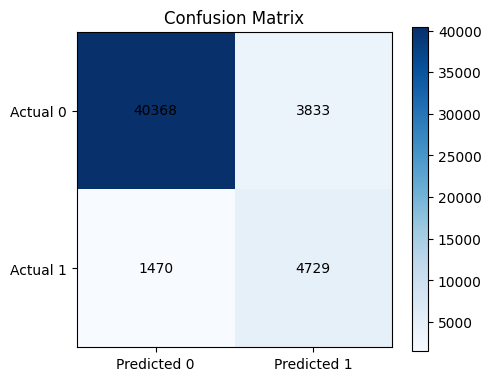

In [7]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred, zero_division=0))

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], ['Predicted 0', 'Predicted 1'])
plt.yticks([0, 1], ['Actual 0', 'Actual 1'])
for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        plt.text(col, row, cm[row, col], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

In [8]:
sample_applicants = pd.DataFrame([
    {
        'Income': 1200000,
        'Age': 35,
        'Experience': 10,
        'Married/Single': 'married',
        'House_Ownership': 'owned',
        'Car_Ownership': 'no',
        'Profession': 'Software_Developer',
        'CITY': 'Mumbai',
        'STATE': 'Maharashtra',
        'CURRENT_JOB_YRS': 8,
        'CURRENT_HOUSE_YRS': 5,
    },
    {
        'Income': 450000,
        'Age': 24,
        'Experience': 2,
        'Married/Single': 'single',
        'House_Ownership': 'rented',
        'Car_Ownership': 'no',
        'Profession': 'Teacher',
        'CITY': 'Indore',
        'STATE': 'Madhya_Pradesh',
        'CURRENT_JOB_YRS': 1,
        'CURRENT_HOUSE_YRS': 1,
    },
])

sample_predictions = model.predict(sample_applicants)
sample_probabilities = model.predict_proba(sample_applicants)[:, 1]

results = sample_applicants.copy()
results['Predicted_Risk_Flag'] = sample_predictions
results['Risk_Probability'] = sample_probabilities
results

,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Predicted_Risk_Flag,Risk_Probability
0,1200000,35,10,married,owned,no,Software_Developer,Mumbai,Maharashtra,8,5,0,0.226205
1,450000,24,2,single,rented,no,Teacher,Indore,Madhya_Pradesh,1,1,0,0.167504
